In [47]:
import pandas as pd
import unidecode
import numpy as np


In [14]:
df_ipp = pd.read_excel('./outputs/df_res.xlsx')
df_evangelicos = pd.read_excel('./data/dados_evangélicos.xlsx')
df_parls_detalhes = pd.read_csv(r'data\df_parl_detalhes.csv')

In [15]:
df_merge = df_ipp.merge(
    df_evangelicos[["id", "idLegislatura", "is_evangelico"]],
    on=["id", "idLegislatura"],
    how="left",
)

# parlamentares detalhes

In [13]:
columns_1 = ['id', 'ultimoStatus.siglaPartido', 'ultimoStatus.siglaUf', 'escolaridade', 'sexo']

In [101]:
df_psm = (
    df_parls_detalhes[columns_1]
    .merge(df_merge[['id', 'is_evangelico']].drop_duplicates(), on='id')
    .join(
        pd.get_dummies(
            df_parls_detalhes["ultimoStatus.siglaPartido"], prefix="siglaPartido_"
        )
    )
    .join(pd.get_dummies(df_parls_detalhes["ultimoStatus.siglaUf"], prefix="siglaUF_"))
    .join(pd.get_dummies(df_parls_detalhes["escolaridade"], prefix="escolaridade_"))
    .join(pd.get_dummies(df_parls_detalhes["sexo"], prefix="sexo_"))
)

df_psm = df_psm.iloc[:, np.r_[:1,5:df_psm.shape[1]]]
df_psm = df_psm.fillna(False).drop_duplicates('id')

# PSM

In [102]:
from psmpy import PsmPy
from psmpy.functions import cohenD

In [106]:
psm = PsmPy(df_psm, treatment='is_evangelico', indx='id', exclude = [])
psm.logistic_ps(balance = True)

In [107]:
df_psm.groupby('id').count().sort_values('is_evangelico')

,is_evangelico,siglaPartido__AVANTE,siglaPartido__CIDADANIA,siglaPartido__DEM,siglaPartido__MDB,siglaPartido__NOVO,siglaPartido__PATRI,siglaPartido__PATRIOTA,siglaPartido__PCB**,siglaPartido__PCdoB,...,escolaridade__Mestrado Incompleto,escolaridade__Primário,escolaridade__Primário Incompleto,escolaridade__Pós-Graduação,escolaridade__Secundário,escolaridade__Secundário Incompleto,escolaridade__Superior,escolaridade__Superior Incompleto,sexo__F,sexo__M
id,,,,,,,,,,,,,,,,,,,,,
1500,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
143254,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
143632,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
143942,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
144523,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74475,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
74476,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
74477,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [108]:
psm.predicted_data

,id,siglaPartido__AVANTE,siglaPartido__CIDADANIA,siglaPartido__DEM,siglaPartido__MDB,siglaPartido__NOVO,siglaPartido__PATRI,siglaPartido__PATRIOTA,siglaPartido__PCB**,siglaPartido__PCdoB,...,escolaridade__Pós-Graduação,escolaridade__Secundário,escolaridade__Secundário Incompleto,escolaridade__Superior,escolaridade__Superior Incompleto,sexo__F,sexo__M,propensity_score,propensity_logit,is_evangelico
0,139265,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.484930,-0.060299,1
1,139276,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,0.475742,-0.097110,1
2,139284,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.493171,-0.027316,1
3,73769,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.426138,-0.297626,1
4,73774,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.430681,-0.279071,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3117,139248,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0.178426,-1.527051,0
3118,139252,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0.178426,-1.527051,0
3119,139251,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0.178426,-1.527051,0
3120,139254,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,0.178426,-1.527051,0


In [109]:
psm.knn_matched(matcher='propensity_logit', replacement=False, caliper=None, drop_unmatched=True)

C:\Users\caca_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\psmpy\psmpy.py:363: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False')


In [110]:
psm.matched_ids

,id,matched_ID
0,139265,74112
1,139276,141386
2,139284,227660
3,73769,133924
4,73774,74166
...,...,...
436,73656,133909
437,73665,139260
438,73667,220591
439,139225,220624


# Comparação das amostras

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

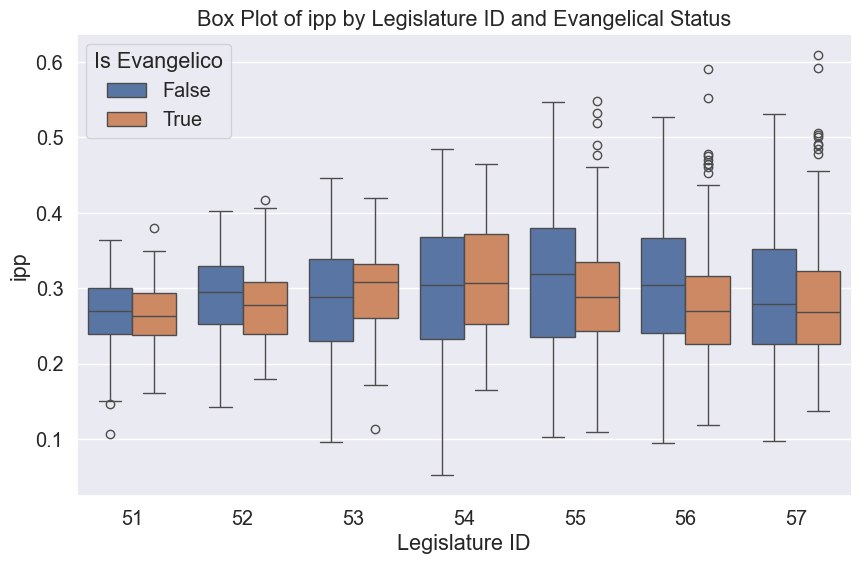

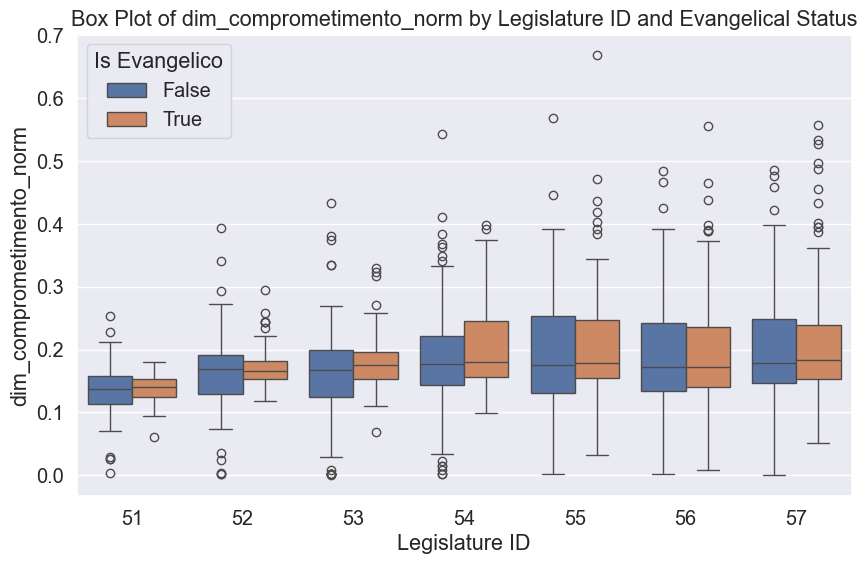

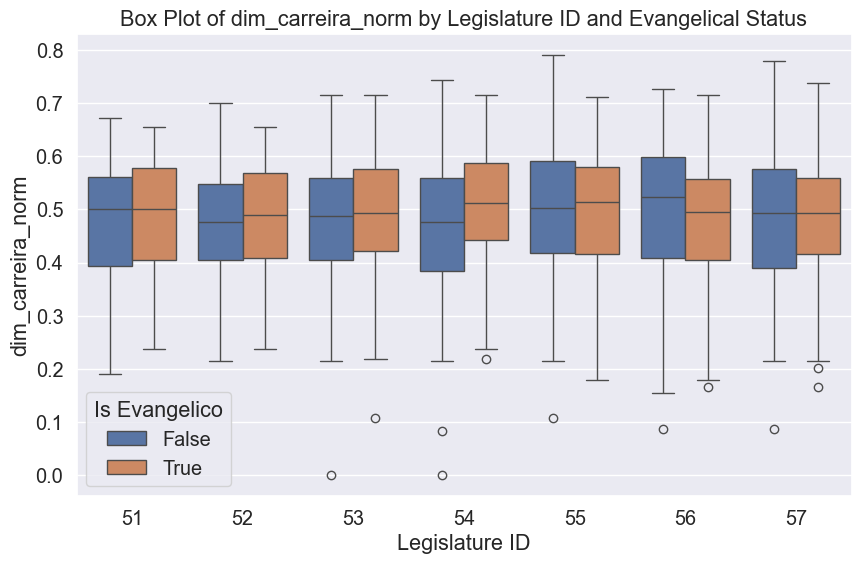

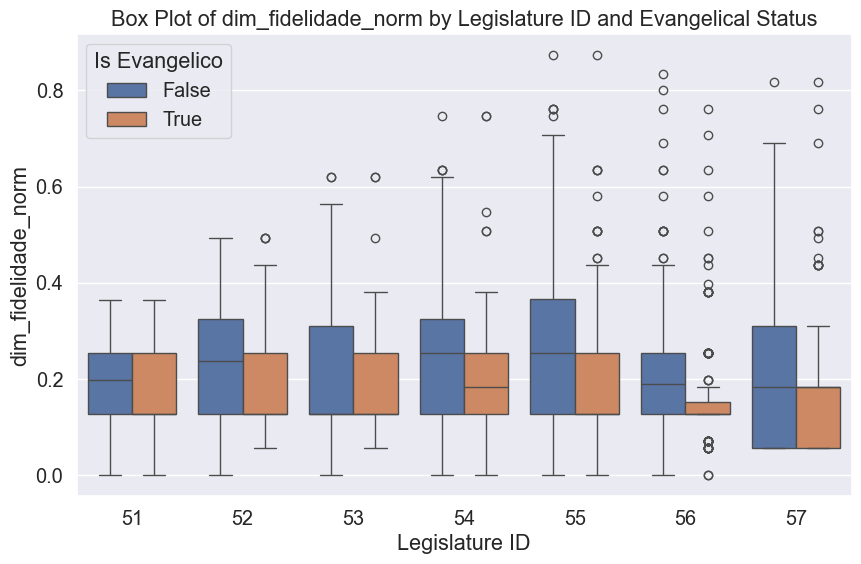

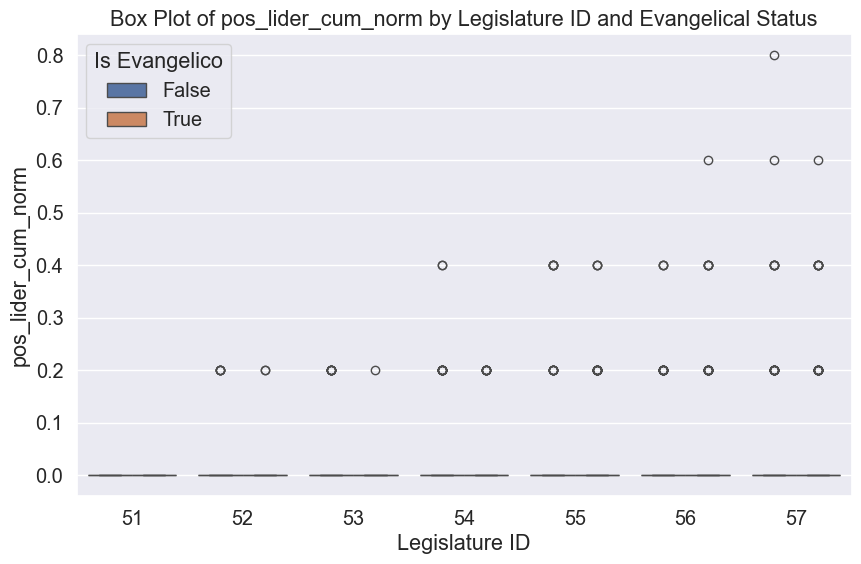

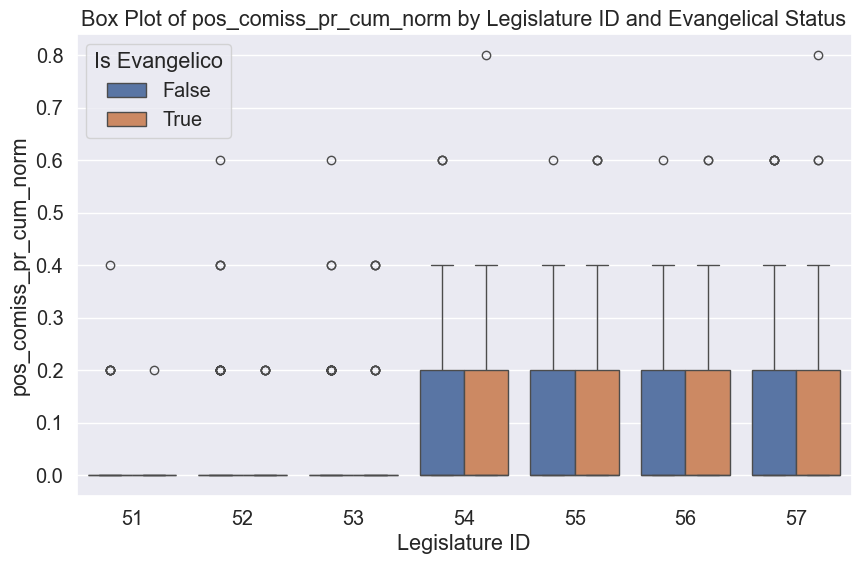

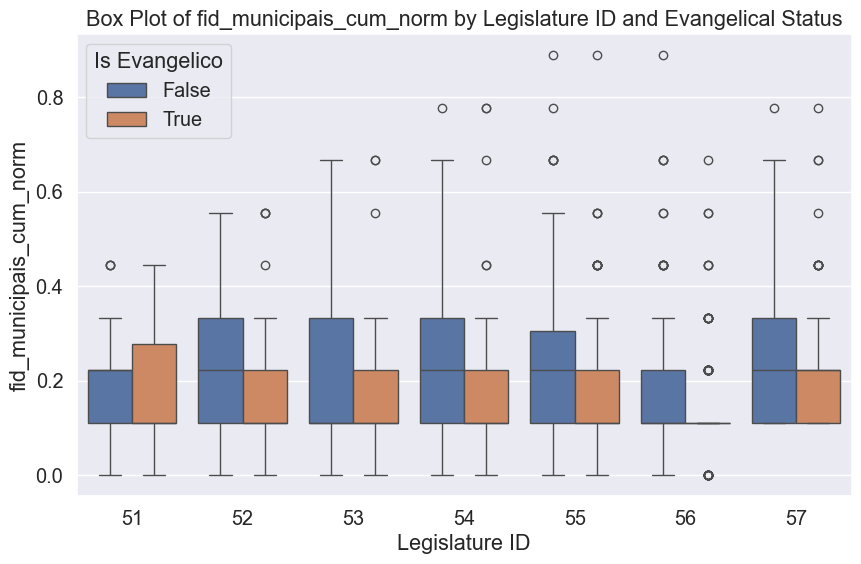

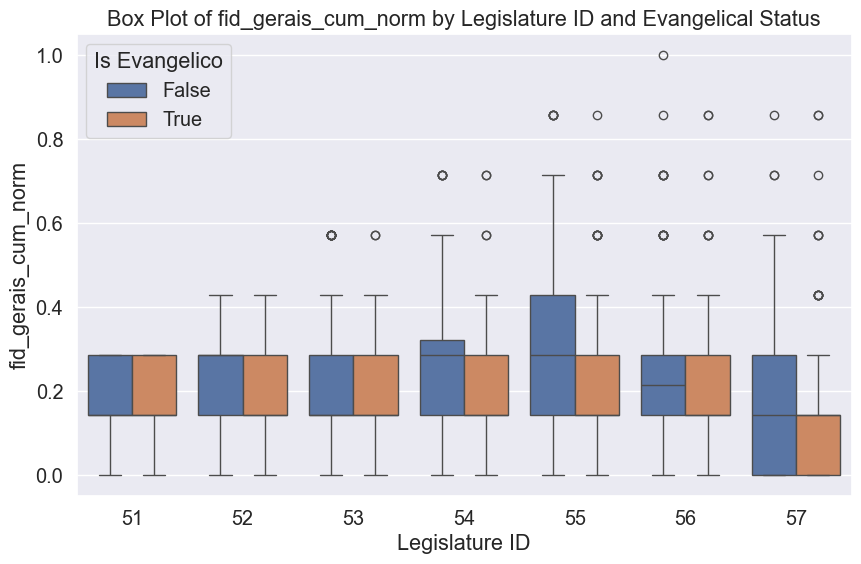

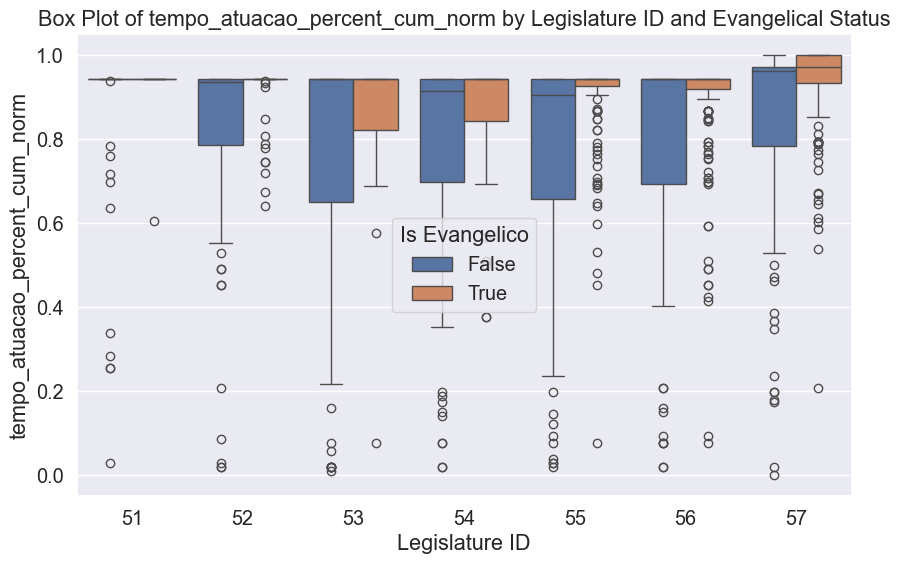

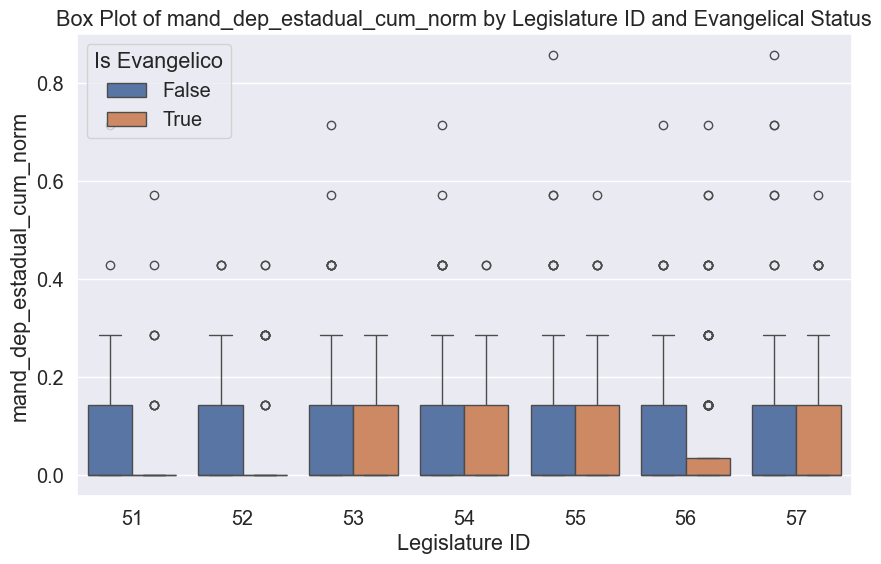

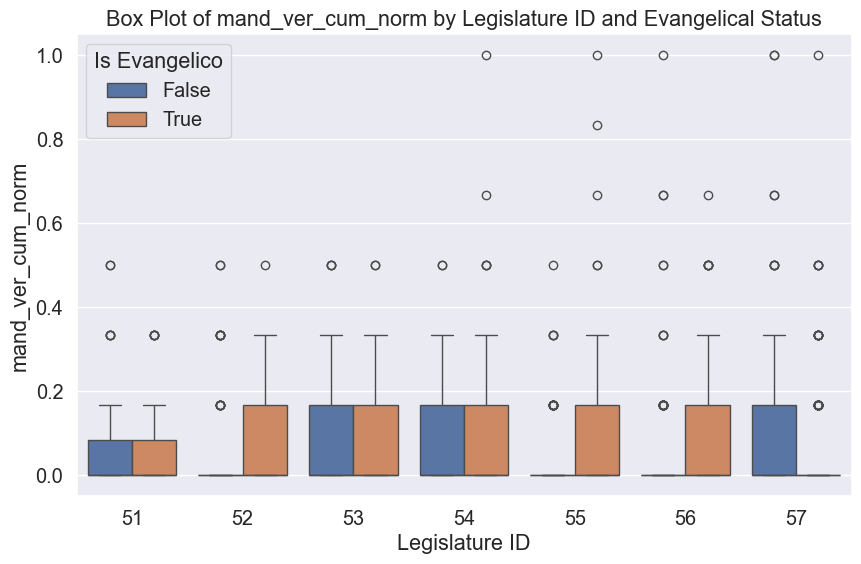

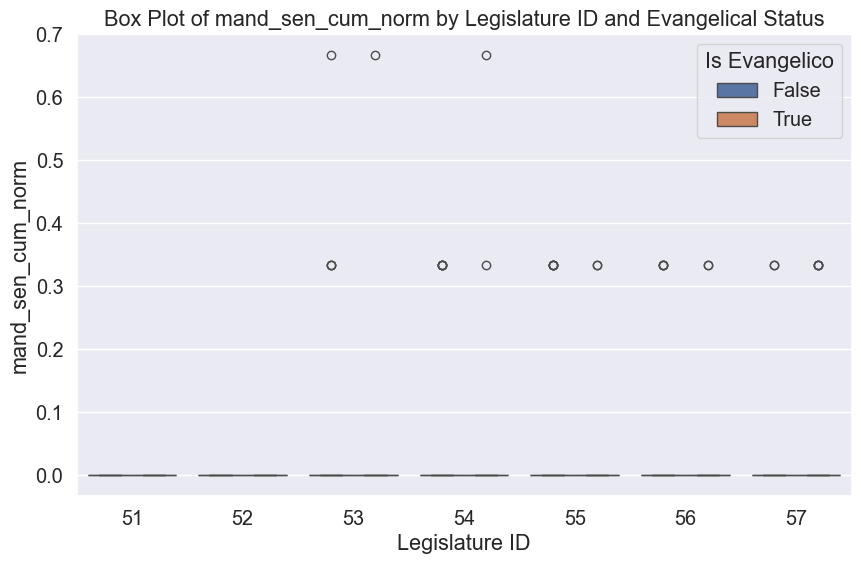

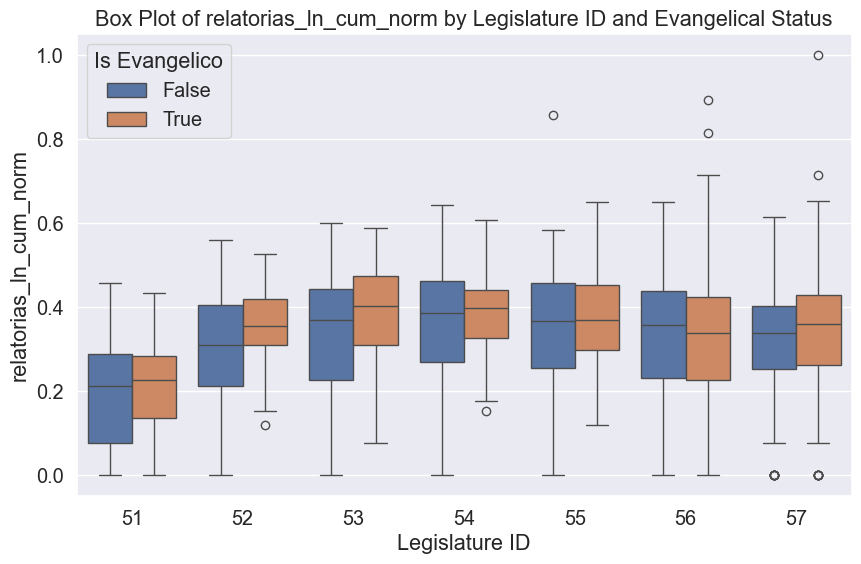

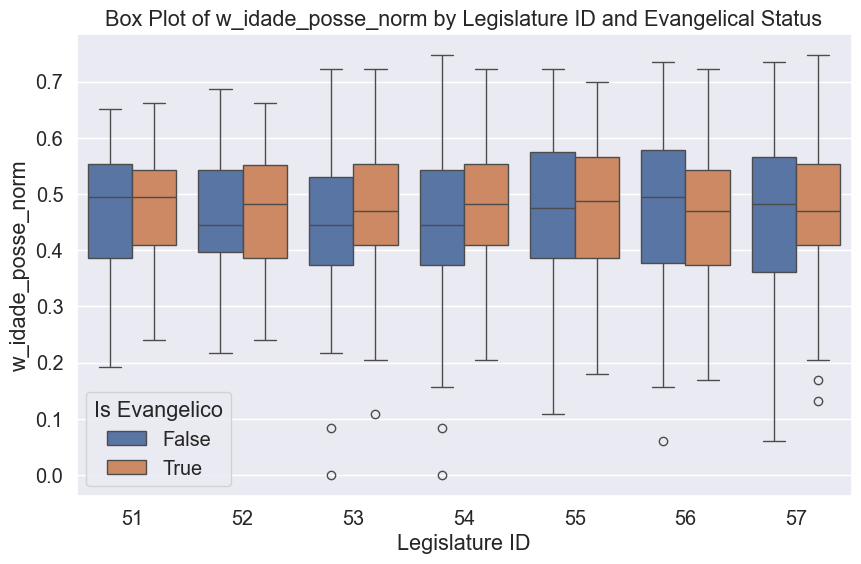

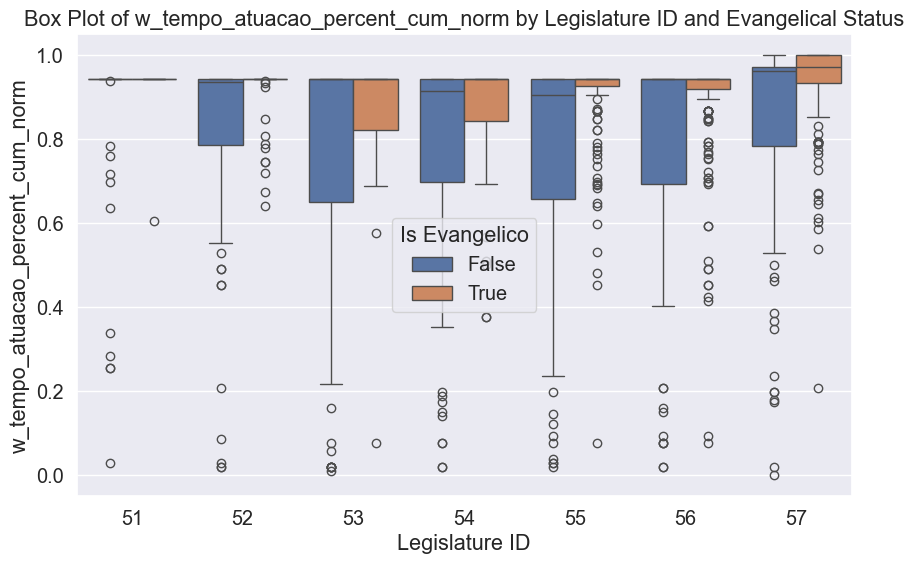

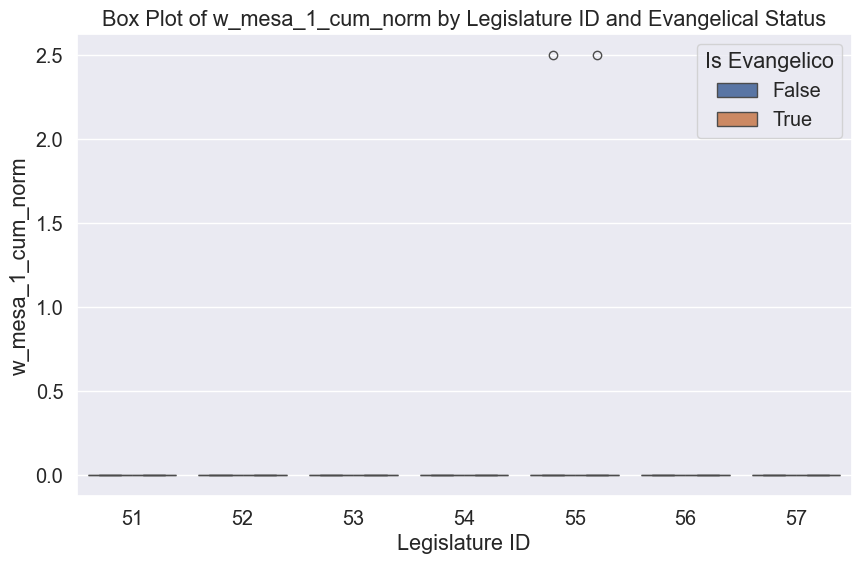

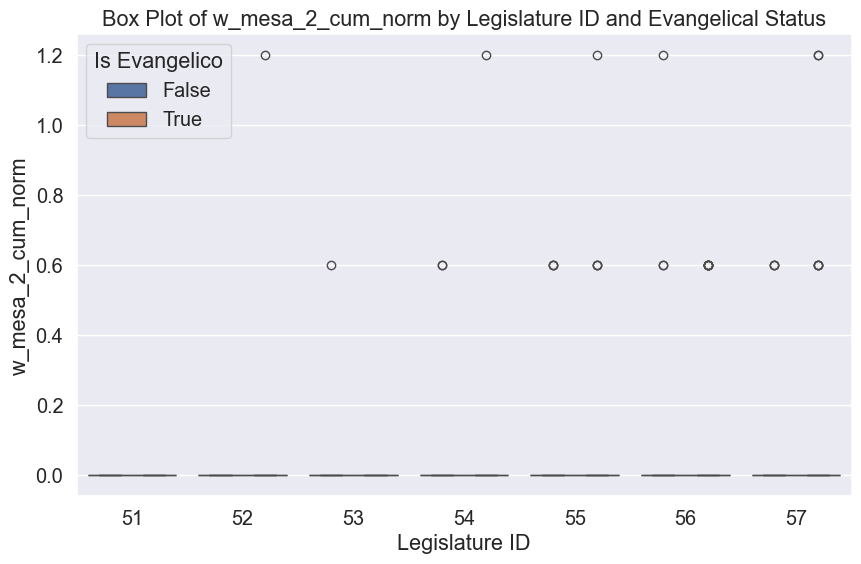

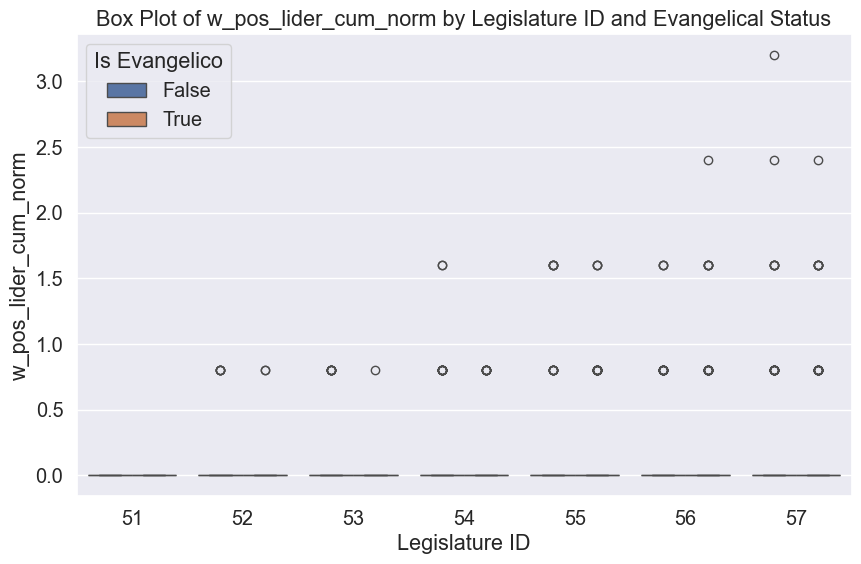

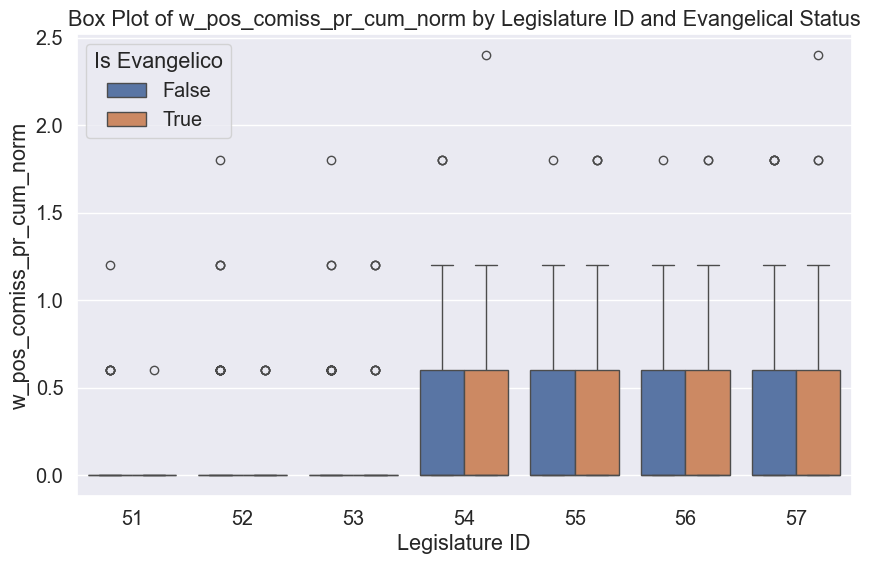

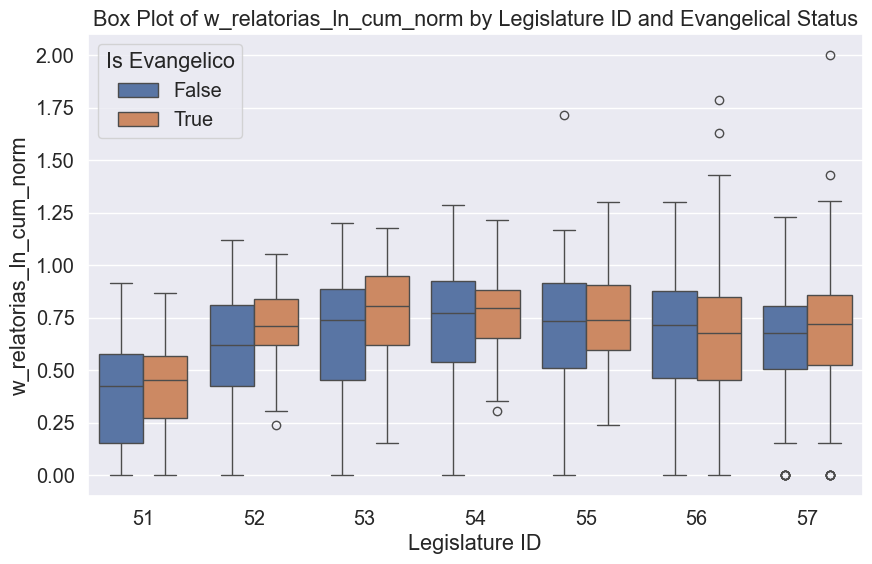

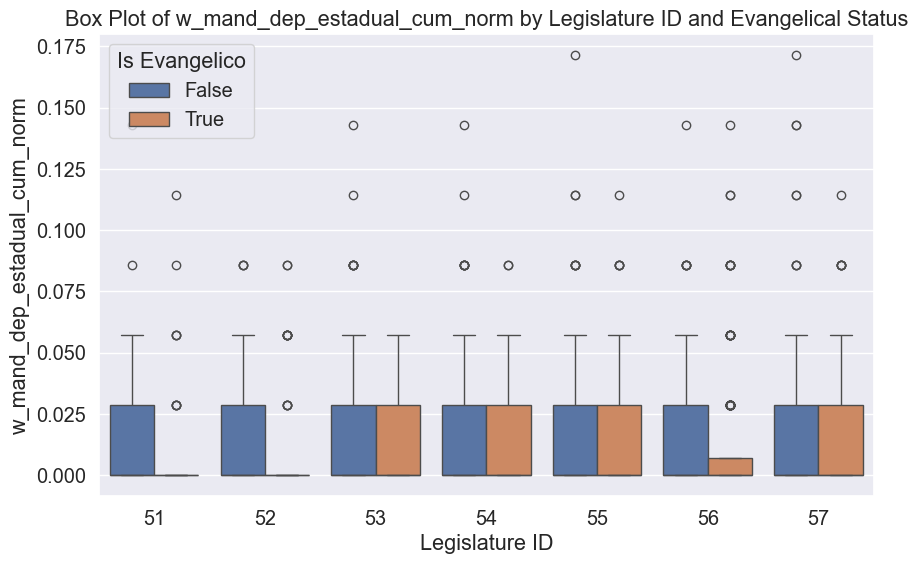

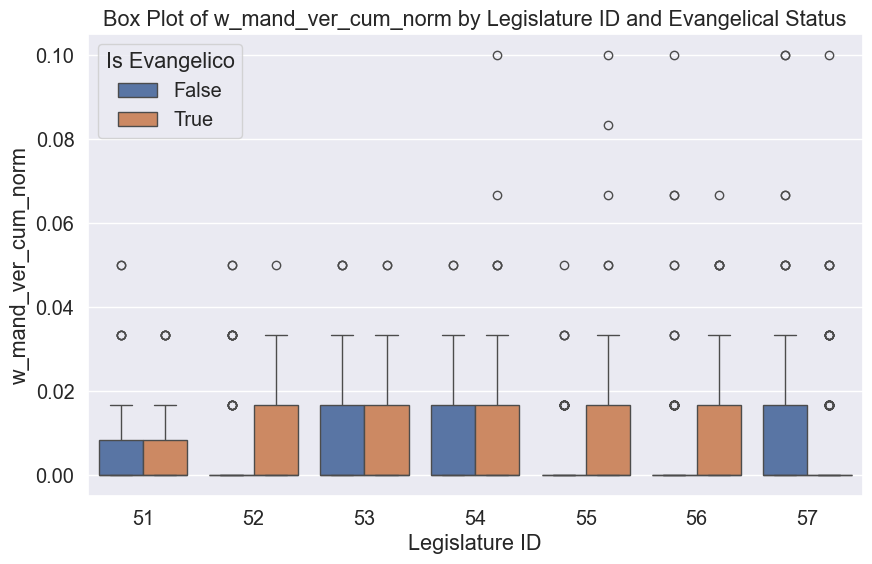

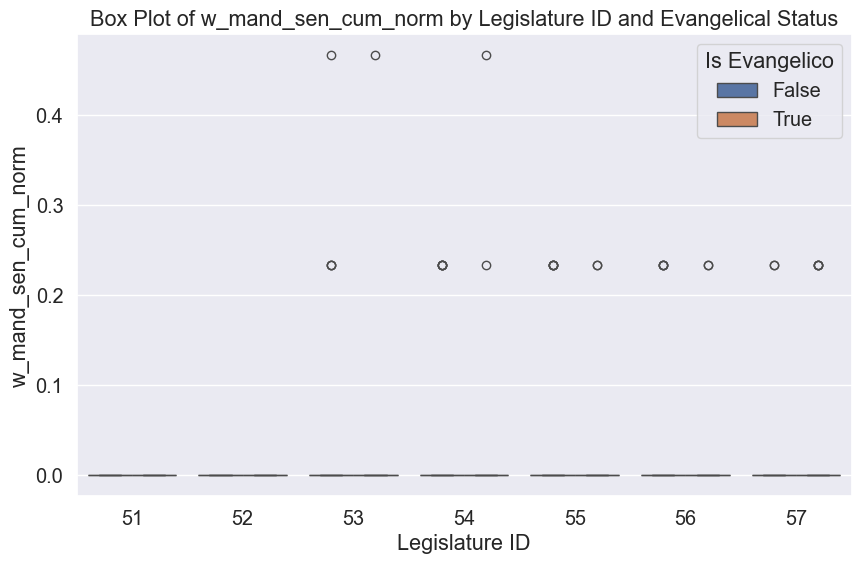

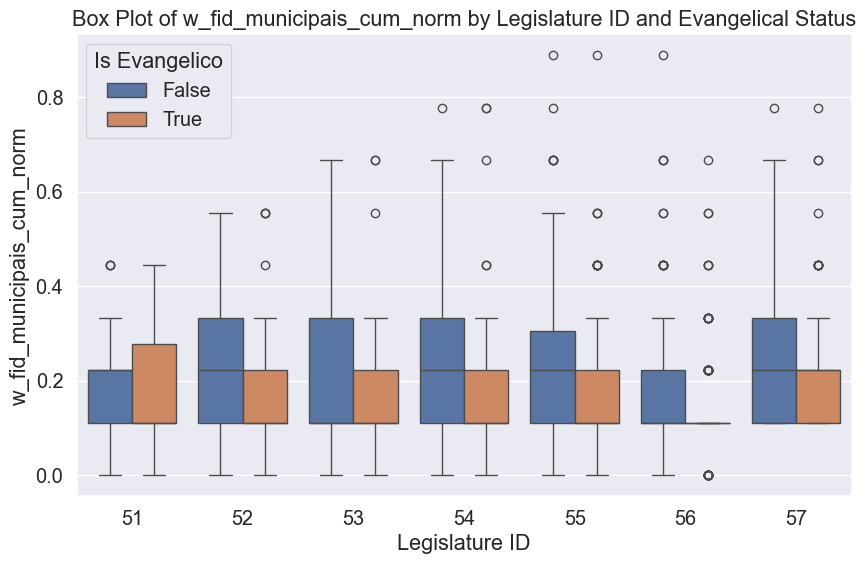

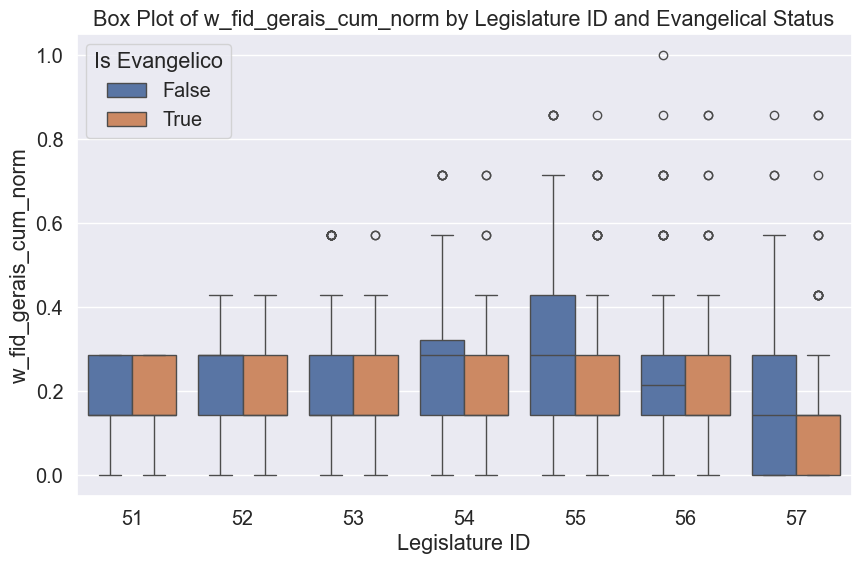

In [131]:
columns_to_evaluate = [
    "ipp",
    "dim_comprometimento_norm",
    "dim_carreira_norm",
    "dim_fidelidade_norm",
    "pos_lider_cum_norm",
    "pos_comiss_pr_cum_norm",
    "fid_municipais_cum_norm",
    "fid_gerais_cum_norm",
    "tempo_atuacao_percent_cum_norm",
    "mand_dep_estadual_cum_norm",
    "mand_ver_cum_norm",
    "mand_sen_cum_norm",
    "relatorias_ln_cum_norm",
    "w_idade_posse_norm",
    "w_tempo_atuacao_percent_cum_norm",
    "w_mesa_1_cum_norm",
    "w_mesa_2_cum_norm",
    "w_pos_lider_cum_norm",
    "w_pos_comiss_pr_cum_norm",
    "w_relatorias_ln_cum_norm",
    "w_mand_dep_estadual_cum_norm",
    "w_mand_ver_cum_norm",
    "w_mand_sen_cum_norm",
    "w_fid_municipais_cum_norm",
    "w_fid_gerais_cum_norm",
]
for column_to_evaluate in columns_to_evaluate:
    df = df_merge[df_merge["id"].isin(psm.df_matched["id"])][
        [column_to_evaluate, "idLegislatura", "is_evangelico"]
    ]


    df = df[df["idLegislatura"] > 50]

    plt.figure(figsize=(10, 6))
    sns.boxplot(x="idLegislatura", y=column_to_evaluate, hue="is_evangelico", data=df)
    plt.xlabel("Legislature ID")
    plt.ylabel(column_to_evaluate)
    plt.title(
        f"Box Plot of {column_to_evaluate} by Legislature ID and Evangelical Status"
    )
    plt.legend(title="Is Evangelico")
    plt.show()

In [124]:
df_merge[df_merge["id"].isin(psm.df_matched["id"])].merge(
    psm.matched_ids, on="id", how="left"
).to_excel("df_evangelicos_ipp_v2.xlsx")